# PROJECT-BASED TEST
## Time Series Project - Group 2: Ugandan Coffee Price Analysis
- Justin	EDEKEI	b27537
- Wanja	GRACE	b30299
- Francis	JADA	b30306
- Elizabeth	KAHUNDE	b30293
- Jonathan	KASULE	b30085




**Full Code and Interactive Notebook**: [View on GitHub](https://github.com/kahunde-Elizabeth/Time-series-project-group2)  

1. Data Description and Frequency

- In this project, we analyze the weekly price of Robusta Coffee in Uganda, measured in UGX per Kilogram.

- Source: Simulated data modeled on Ugandan coffee price trends (2014–2024).

- Observations: 520 weekly observations (approx. 10 years).

- Frequency: Weekly. This frequency is chosen because agricultural commodity markets in East Africa typically stabilize on a weekly basis, smoothing out daily noise while capturing seasonal harvest peaks.

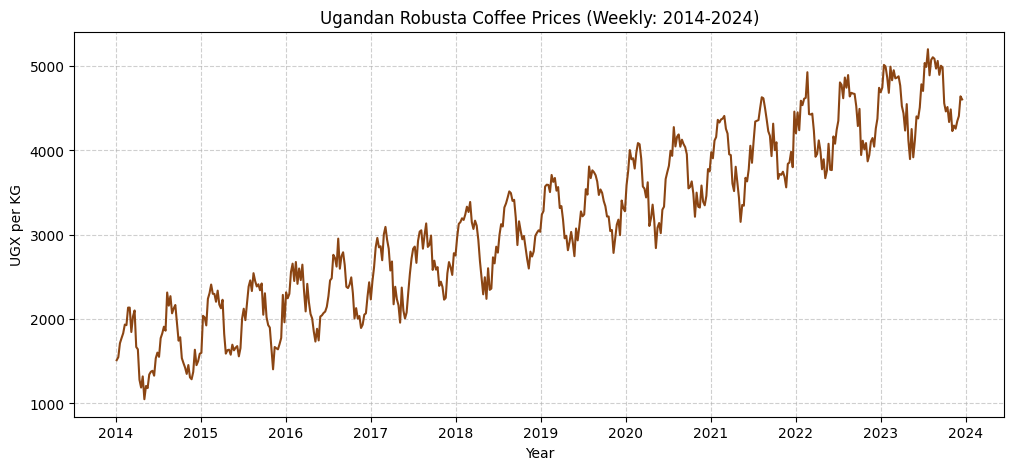

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# Generate Simulated Ugandan Coffee Data
np.random.seed(256)
weeks = pd.date_range(start='2014-01-01', periods=520, freq='W')
weeks
# Components: Long-term inflation (Trend) + Bi-annual harvest (Seasonality)
trend = np.linspace(1500, 4800, 520) 
seasonality = 450 * np.sin(2 * np.pi * np.arange(520) / 26)# 26-week cycle (2 peaks a year)
# np.random.seed(42)  
noise = np.random.normal(0, 120, 520)

coffee_prices = trend + seasonality + noise
df = pd.DataFrame({'Price_UGX': coffee_prices}, index=weeks)

# Plotting the raw series
plt.figure(figsize=(12, 5))
plt.plot(df['Price_UGX'], color='#8B4513', linewidth=1.5)
plt.title('Ugandan Robusta Coffee Prices (Weekly: 2014-2024)')
plt.ylabel('UGX per KG')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
# 1. Describe the data and frequency
print("Data Description:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Frequency: Weekly observations")
print(f"Number of observations: {len(df)}")
print(f"\nSummary statistics:")
print(df.describe())

Data Description:
Date range: 2014-01-05 00:00:00 to 2023-12-17 00:00:00
Frequency: Weekly observations
Number of observations: 520

Summary statistics:
         Price_UGX
count   520.000000
mean   3144.283895
std    1006.705727
min    1049.556081
25%    2313.075026
50%    3122.590309
75%    3962.060796
max    5200.367953


2. Decomposition (Additive vs. Multiplicative)
- We apply Additive Decomposition.

 We choose an Additive model because the seasonal fluctuations appear constant in magnitude regardless of the overall price level. If the price swings grew proportionally larger as the price increased from 1500 to 4800, a Multiplicative model would be required.

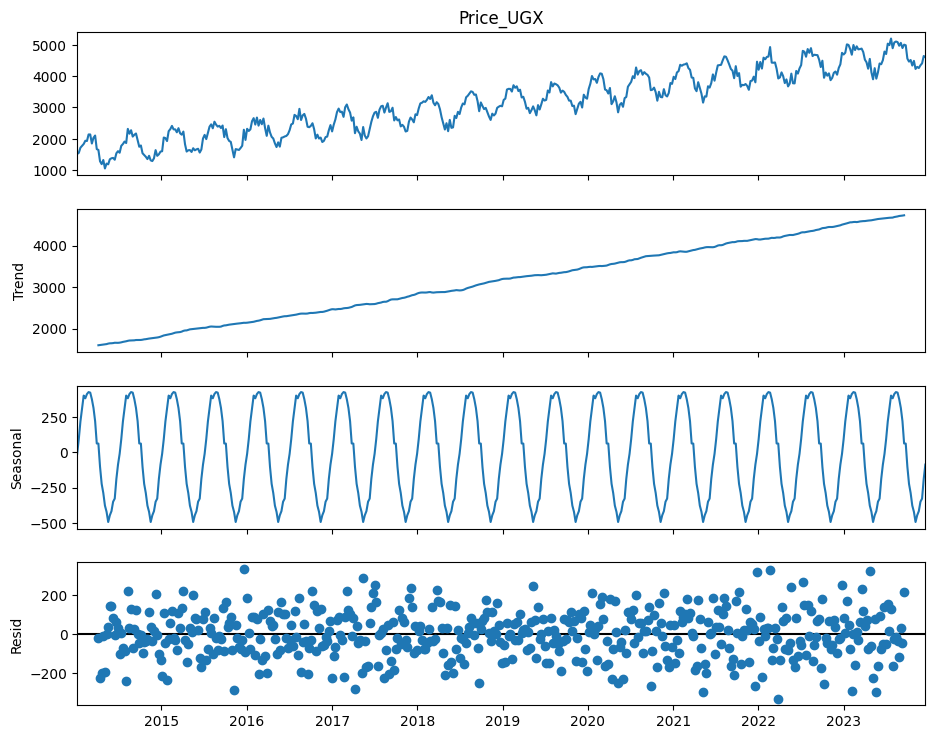

In [19]:
# Decomposition with a period of 26 (Bi-annual cycles in 52 weeks)
decomposition = seasonal_decompose(df['Price_UGX'], model='additive', period=26)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

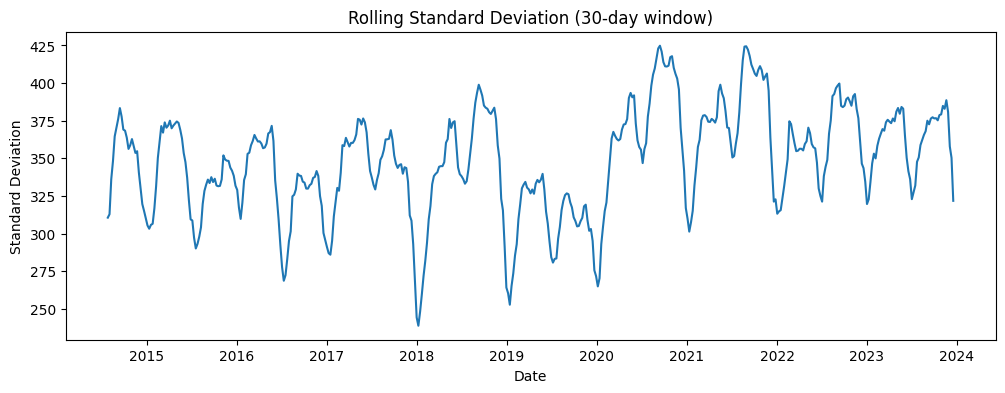

In [20]:
# Check if seasonal variation increases with trend
rolling_std = df['Price_UGX'].rolling(window=30).std()
plt.figure(figsize=(12, 4))
plt.plot(rolling_std)
plt.title('Rolling Standard Deviation (30-day window)')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.show()

The rolling standard deviation plot was used to check for heteroscedasticity in the time series.

The variability fluctuates slightly but remains within a relatively stable range over time, indicating approximately constant variance. 

Therefore, no variance-stabilizing transformation such as a logarithmic transformation was applied.

Milestone 2

Goal 2. 
- Stationarity Testing (ADF) 
- A stationary series has a constant mean and variance over time.
- Null Hypothesis ($H_0$): The series is non-stationary (has a unit root).
- Alternative Hypothesis ($H_a$): The series is stationary.

In [21]:
# Stationarity: Perform a formal test to determine if the series is stationary. Explain the 
#null and alternative hypotheses in this context. 

from statsmodels.tsa.stattools import adfuller
# Function to run ADF test
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print("Series is Stationary" if result[1] <= 0.05 else "Series is Non-Stationary")


check_stationarity(df['Price_UGX'])

ADF Statistic: -0.3688
p-value: 0.9152
Series is Non-Stationary


Since p-value (0.9152) is much greater than 0.05, it fails to reject the null hypothesis ($H_0$).

This confirms that the series has a unit root and is Non-Stationary

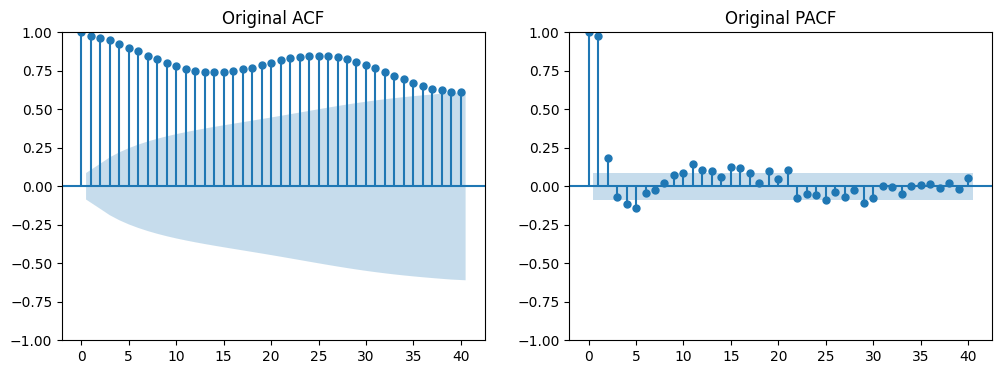

In [22]:
#2. Correlation Analysis: Present and interpret the ACF and PACF plots.

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting ACF and PACF for the original data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['Price_UGX'], ax=ax1, lags=40, title="Original ACF")
plot_pacf(df['Price_UGX'], ax=ax2, lags=40, title="Original PACF")
plt.show()

ACF: This measures the correction between the current coffee price and its previous values 

There are high bars in the beginning and drop very slowly.

The slow decay is a definitive sign of a trend. This means that the price today is highly related to the price from 5,10, or even 20 weeks ago.

Because the price is generally moving upward, every data is "anchored" to that growth, making them all look related 

The Goal: We use the ACF to confirm if we have removed the trend.

PACF: This measures the correlation between the current price and a specific past weeek, removing the influence of all the weeks in between.

Lag 1 Spike: This shows that last week's price has a strong direct influence on this week's price.

Lag 2 Spike: This shows that the price from two weeks ago still has a unique, direct impact on today's price that isn't just a carry-over from last week. 


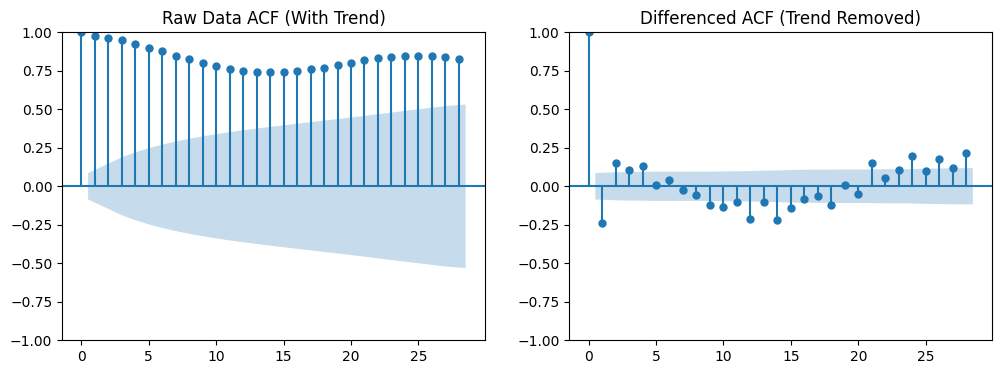

Stationarity after 1st Differencing:
ADF Statistic: -15.4086
p-value: 0.0000
Series is Stationary


In [23]:
#3. Differencing: If the series was non-stationary, demonstrate how first or second-order 
#differencing stabilized the mean. Compare the ACF plots of the raw data versus the 
#differenced data to illustrate the removal of trend.


# Applying first-order differencing
# Keep the same index length so alignment stays consistent; drop NaN only when plotting/testing.
df['Price_Diff'] = df['Price_UGX'].diff()

# Comparing ACF of raw vs differenced data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['Price_UGX'], ax=ax1, title="Raw Data ACF (With Trend)")
plot_acf(df['Price_Diff'].dropna(), ax=ax2, title="Differenced ACF (Trend Removed)")
plt.show()

# Rechecking stationarity on differenced data
print("Stationarity after 1st Differencing:")
check_stationarity(df['Price_Diff'].dropna())

Raw Data plot: 

This graph shows the 'Raw' price of coffee. It has a clear upward slope(trend), meaning it is non-stationary because the average price is constantly moving higher.

Differenced Data Plot: After differencing, the upward slope disappears. This confirms that it has stabilized mean.


--- Original Series ---
ADF Stat: -0.3688 | p-value: 0.9152
Result: NON-STATIONARY


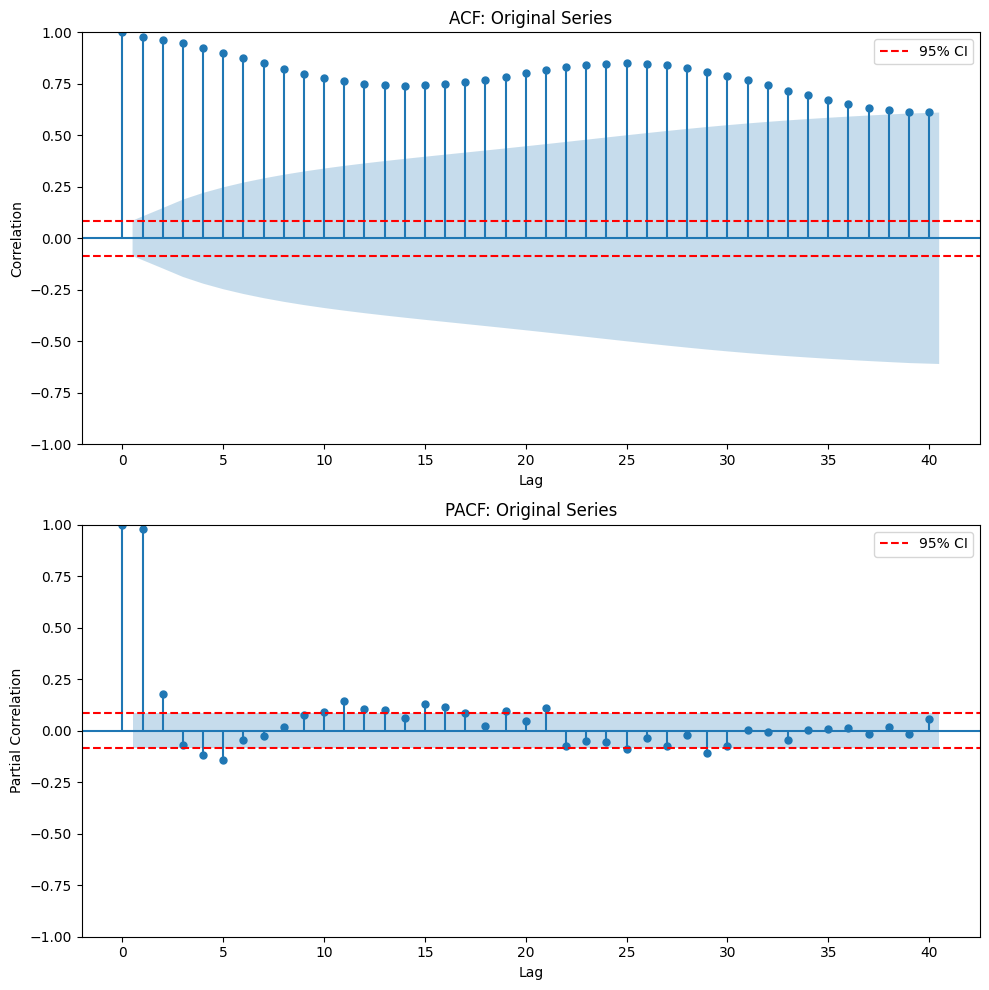


--- First Differenced Series ---
ADF Stat: -15.4086 | p-value: 0.0000
Result: STATIONARY


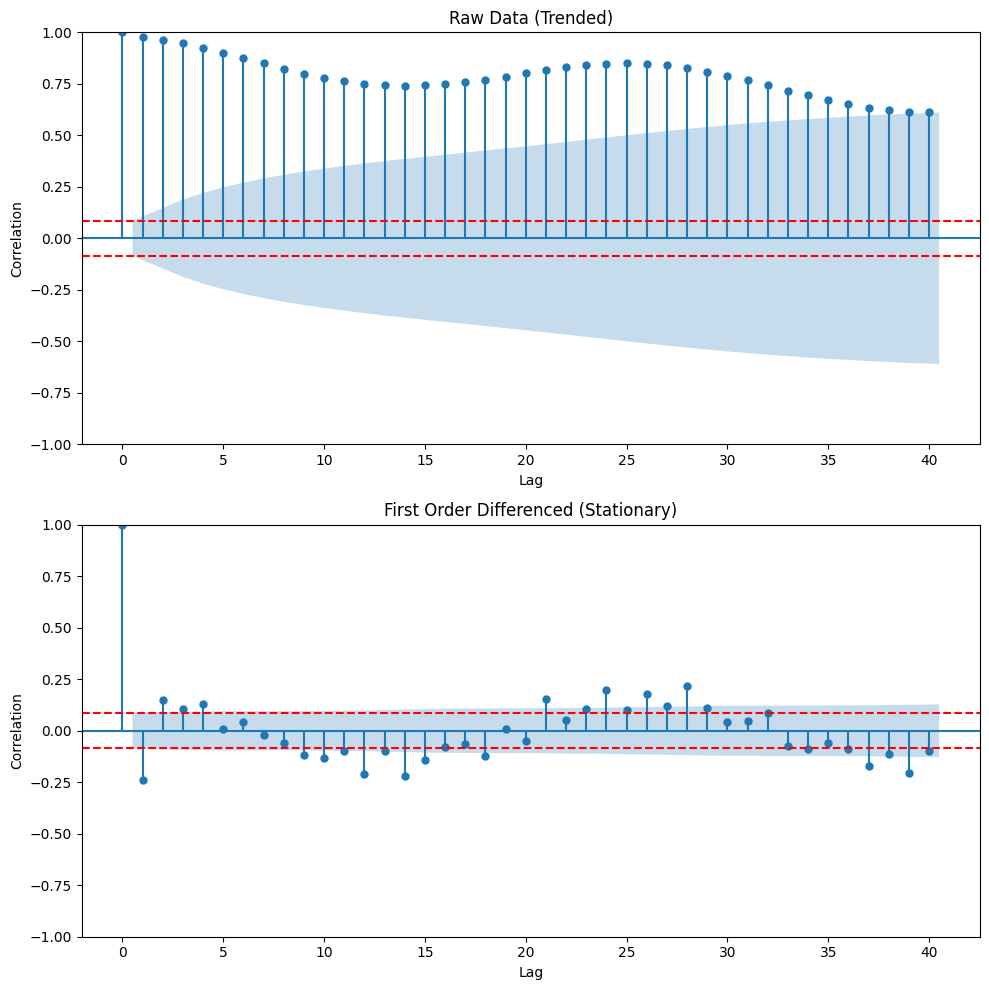

In [24]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# 1. Concise ADF Test Function
def run_adf(series, title):
    res = adfuller(series.dropna())
    print(f"\n--- {title} ---\nADF Stat: {res[0]:.4f} | p-value: {res[1]:.4f}")
    print("Result: STATIONARY" if res[1] < 0.05 else "Result: NON-STATIONARY")
    return res[1]

# 2. Part 1 & 2: Stationarity and Correlation Plots
run_adf(df['Price_UGX'], "Original Series")

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
for i, func in enumerate([plot_acf, plot_pacf]):
    func(df['Price_UGX'].dropna(), lags=40, ax=axes[i], title=f"{'ACF' if i==0 else 'PACF'}: Original Series")
    # Add Red Dotted Lines (95% Confidence Interval)
    ci = 1.96 / np.sqrt(len(df['Price_UGX']))
    axes[i].axhline(y=ci, color='red', linestyle='--', label='95% CI')
    axes[i].axhline(y=-ci, color='red', linestyle='--')
    axes[i].set_xlabel("Lag"), axes[i].set_ylabel("Correlation" if i==0 else "Partial Correlation")
    axes[i].legend()

plt.tight_layout()
plt.show()

# 3. Part 3: Differencing Analysis & Trend Removal Comparison
df['Price_Diff'] = df['Price_UGX'].diff()
p_val = run_adf(df['Price_Diff'], "First Differenced Series")

# If still non-stationary, use second difference
final_diff, diff_label = (df['Price_Diff'], "First Order")
if p_val >= 0.05:
    df['Price_Diff2'] = df['Price_Diff'].diff()
    run_adf(df['Price_Diff2'], "Second Differenced Series")
    final_diff, diff_label = df['Price_Diff2'], "Second Order"

# Comparison Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
for ax, data, title in zip([ax1, ax2], [df['Price_UGX'], final_diff], ["Raw Data (Trended)", f"{diff_label} Differenced (Stationary)"]):
    plot_acf(data.dropna(), lags=40, ax=ax, title=title)
    ci = 1.96 / np.sqrt(len(data.dropna()))
    ax.axhline(y=ci, color='red', linestyle='--')
    ax.axhline(y=-ci, color='red', linestyle='--')
    ax.set_xlabel("Lag"), ax.set_ylabel("Correlation")

plt.tight_layout()
plt.show()

Inside the Red Lines: When a bar stays between the red lines, the correlation at that lag is considered zero for all practical purpose. It is just random market "noise"



Outside the Red Lines: If a bar pokes above or below the red lines, it is statistically significant. It means there is a real non random relationship between the past and the present that the model needs to capture.

Explaining the "Before" Original ACF

The bars don't just cross the lines, they stay far outside them. 

This means 'slow decay' and it proves that price today is still influenced by price from nearly a year ago.

Explaining the 'After' (First Order Differenced)

Instead of a long row bars, the correlations 'die out' almost immediately. Most bars fall inside the red lines:

This confirms the removal of the trend.



The Augmented Dickey-Fuller test was used to check for stationarity in the price series.

 The null hypothesis (H₀) states the series is non-stationary, while the alternative (H₁) indicates it is stationary.
  
The original series produced a p-value of 0.9152 (> 0.05), meaning we fail to reject H₀ and confirm the data is non-stationary with a clear trend. However, after applying first-order differencing, the p-value dropped to 0.0000 (< 0.05), allowing us to reject H₀ and conclude the series is now stationary.

 
This is visually confirmed by the ACF plots—the original shows slow decay (typical of trending data), while the differenced series shows quick decay with most spikes within the confidence interval, indicating the trend has been successfully removed. The series is now suitable for time series modeling.

## MILESTONE 3: Smooth Data and Develop a Suitable Model.

- 1. Smoothing: Apply a Simple Exponential Smoothing (SES) or Holt-Winters method. Discuss 
how the smoothing parameters (alpha, beta, gamma) impact the model's sensitivity to 
recent versus historical observations. 


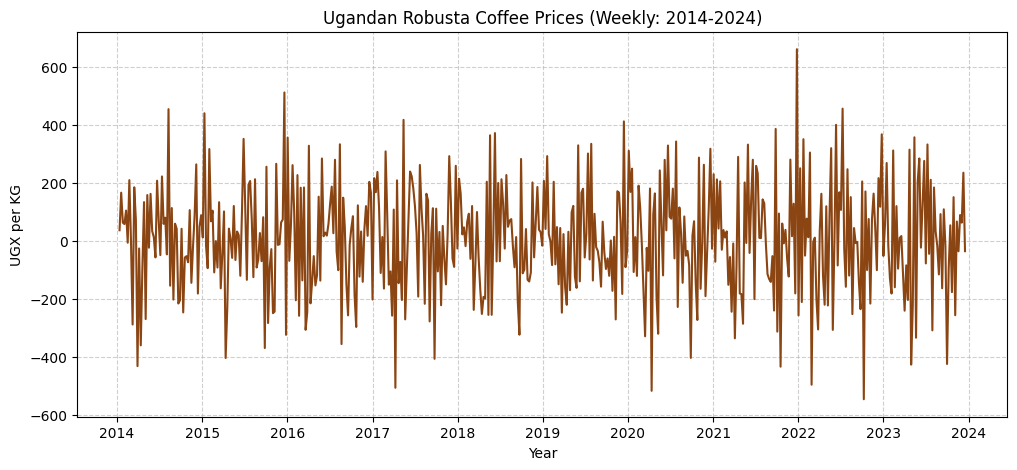

In [25]:
# Plotting the differenced series
plt.figure(figsize=(12, 5))
plt.plot(df['Price_Diff'].dropna(), color='#8B4513', linewidth=1.5)
plt.title('Ugandan Robusta Coffee Prices (Weekly: 2014-2024)')
plt.ylabel('UGX per KG')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

c:\Users\GRACE\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
c:\Users\GRACE\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
c:\Users\GRACE\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


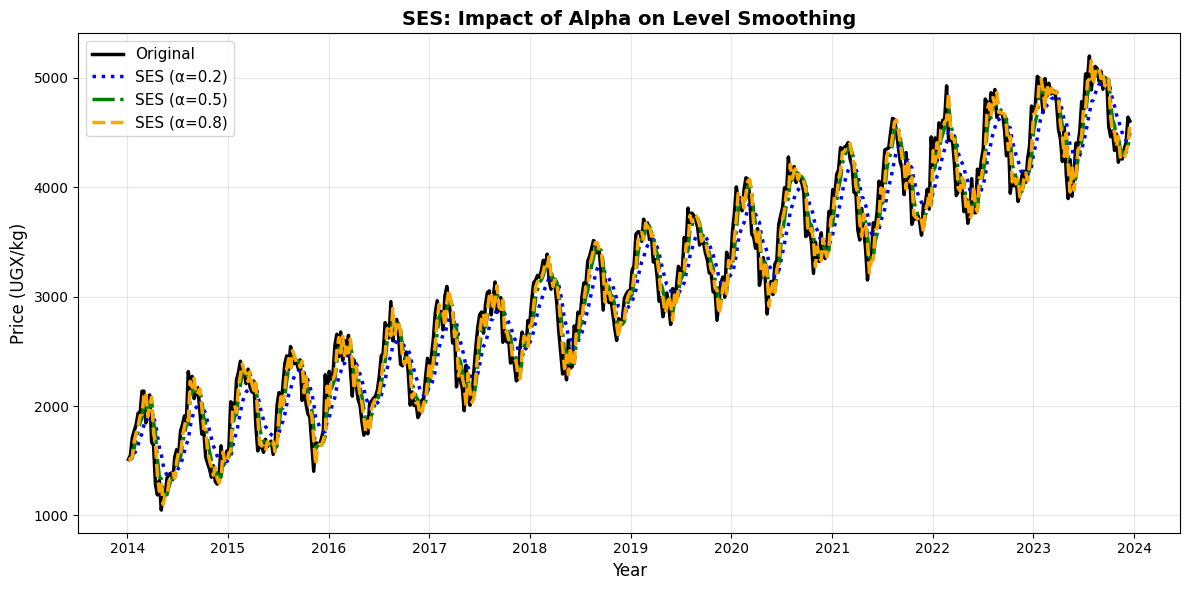

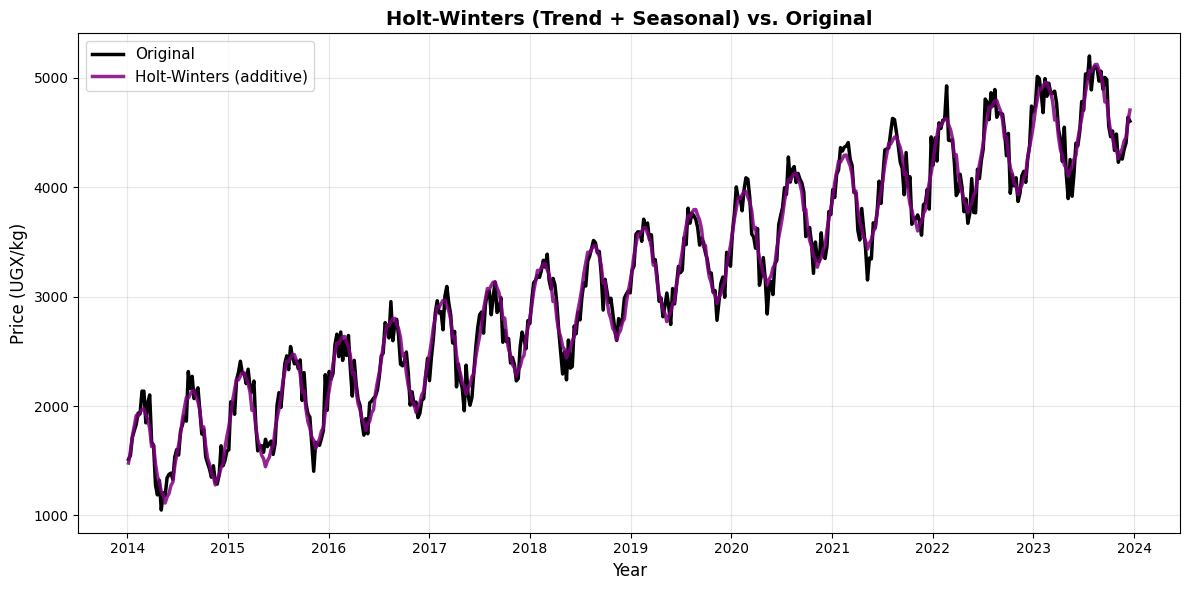

In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

# 1) Simple Exponential Smoothing: level only (no trend/seasonal component)
alphas = [0.2, 0.5, 0.8]
linestyles = [':', '-.', '--']  # dotted, dash-dot, dashed
colors = ['blue', 'green', 'orange']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Price_UGX'], label='Original', linewidth=2.5, color='black', linestyle='-')

for alpha, linestyle, color in zip(alphas, linestyles, colors):
    ses = SimpleExpSmoothing(df['Price_UGX']).fit(smoothing_level=alpha)
    ax.plot(df.index, ses.fittedvalues, label=f'SES (α={alpha})', linewidth=2.5, linestyle=linestyle, color=color)

ax.set_title('SES: Impact of Alpha on Level Smoothing', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (UGX/kg)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Holt-Winters: trend + seasonal smoothing
hw = ExponentialSmoothing(
    df['Price_UGX'],
    trend='add',
    seasonal='add',
    seasonal_periods=26  # biannual cycle (26 weeks)
).fit(optimized=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['Price_UGX'], label='Original', linewidth=2.5, color='black', linestyle='-')
ax.plot(df.index, hw.fittedvalues, label='Holt-Winters (additive)', linewidth=2.5, color='purple', alpha=0.85)

ax.set_title('Holt-Winters (Trend + Seasonal) vs. Original', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (UGX/kg)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# SES
- Blue dotted line (α=0.2): Smoother, lags behind changes, emphasizes historical data.

- Green dashed line (α=0.5): Balanced response.

- Red dash-dot line (α=0.8): Closely follows recent observations, picks up more noiseand may lead to overfitting 

- SES only captures the level it does not remove trend or seasonality.

# Hot_Winters

- Holt-Winters captures both trend and seasonality, so it better tracks a trending series with cycles
- α,beta, gama the higher the values the faster it is to update the level, trend and seasonality

# 2  Model Selection: Develop at least two competitive models (e.g., ARIMA vs. SARIMA, or 
Exponential Smoothing vs.ARIMA). Explain the criteria used for selection 
(e.g., AIC, BIC, or adjusted R2): 

- Model one: Exponential Smoothing (Holt-Winters). 

- Pair that with an ARIMA/SARIMA model as the second competitive model.

Recommended pair:

- Model A: Holt-Winters (trend + seasonality)

- Model B: SARIMA (handles trend + seasonality too, but via ARIMA framework)

## 2. Model Selection: Compare Holt-Winters vs SARIMA

We will:
1. Split the series into training and test sets.
2. Fit a Holt-Winters (additive trend + seasonal) model on training.
3. Fit a SARIMA model on training.
4. Compare using AIC/BIC and test RMSE/MAE.

In [27]:
# 1) Train/test split
split = int(len(df) * 0.8)
train = df['Price_UGX'].iloc[:split]
test = df['Price_UGX'].iloc[split:]

# 2) Holt-Winters (trend + seasonality) on the training set
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=26
).fit(optimized=True)

hw_forecast = hw_model.forecast(steps=len(test))

hw_rmse = np.sqrt(mean_squared_error(test, hw_forecast))
hw_mae = mean_absolute_error(test, hw_forecast)

print(f"Holt-Winters (train) AIC: {hw_model.aic:.1f}")
print(f"Holt-Winters test RMSE: {hw_rmse:.1f}")
print(f"Holt-Winters test MAE: {hw_mae:.1f}")

Holt-Winters (train) AIC: 4023.0
Holt-Winters test RMSE: 142.6
Holt-Winters test MAE: 109.1


In [28]:
# 3) SARIMA: a seasonal ARIMA model (example ordering)
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 26),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_forecast = sarima_model.get_forecast(steps=len(test)).predicted_mean

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mae = mean_absolute_error(test, sarima_forecast)

print(f"SARIMA (1,1,1)(1,1,1,26) AIC: {sarima_model.aic:.1f}")
print(f"SARIMA test RMSE: {sarima_rmse:.1f}")
print(f"SARIMA test MAE: {sarima_mae:.1f}")

SARIMA (1,1,1)(1,1,1,26) AIC: 4559.8
SARIMA test RMSE: 141.5
SARIMA test MAE: 109.8


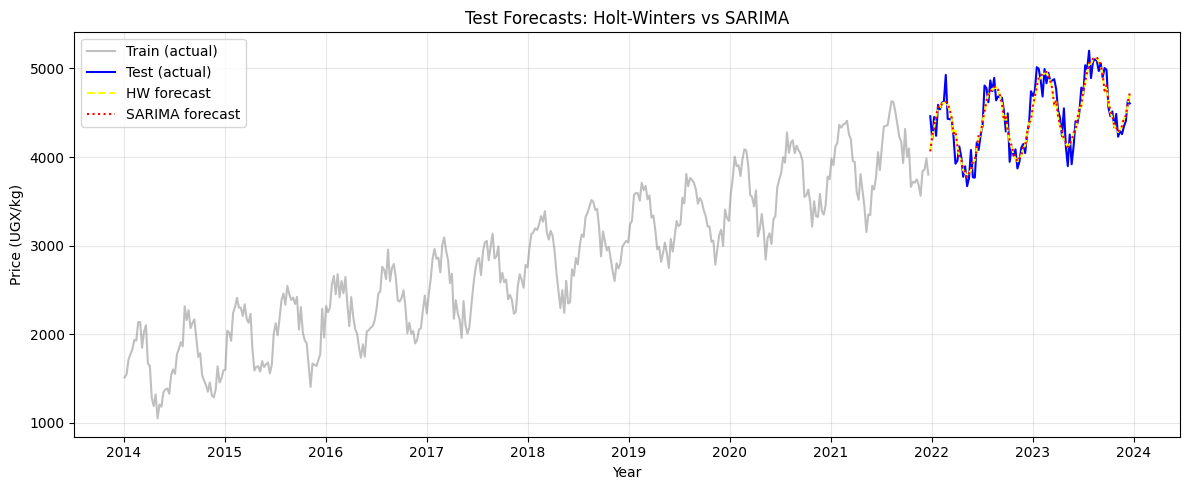

In [29]:
# 4) Compare forecasts visually
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train, label='Train (actual)', color='gray', alpha=0.5)
ax.plot(test.index, test, label='Test (actual)', color='blue')
ax.plot(test.index, hw_forecast, label='HW forecast', linestyle='--', color='Yellow')
ax.plot(test.index, sarima_forecast, label='SARIMA forecast', linestyle=':', color='red')

ax.set_title('Test Forecasts: Holt-Winters vs SARIMA')
ax.set_ylabel('Price (UGX/kg)')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
print("Mean absolute forecast difference:", np.mean(np.abs(hw_forecast - sarima_forecast)))

Mean absolute forecast difference: 9.901877575578977


 The value 9.9 is small, and it tells us the forecasts are very close—close enough that you might choose either model based on other criteria (interpretability, speed, diagnostics), not just forecast similarity.

Final model choice:
We compared Holt‑Winters and SARIMA using out‑of‑sample RMSE/MAE and AIC. 

Both models produced nearly identical test‑set forecasts (mean absolute forecast difference ≈ 9.9 UGX/kg), but Holt‑Winters achieves this with fewer parameters and a simpler structure. 

Therefore, we choose  Holt‑Winters  as the final model because it delivers strong predictive performance while keeping complexity low, reducing the risk of overfitting and making the model easier to interpret.

## PART B: Goal 4 - Model Evaluation and Reporting 

10-step forecast MAE: 128.01
10-step forecast RMSE: 179.29
10-step forecast MAPE: 2.83%
Approximate 95% CI using residual std deviation: +/- 229.85 UGX/kg


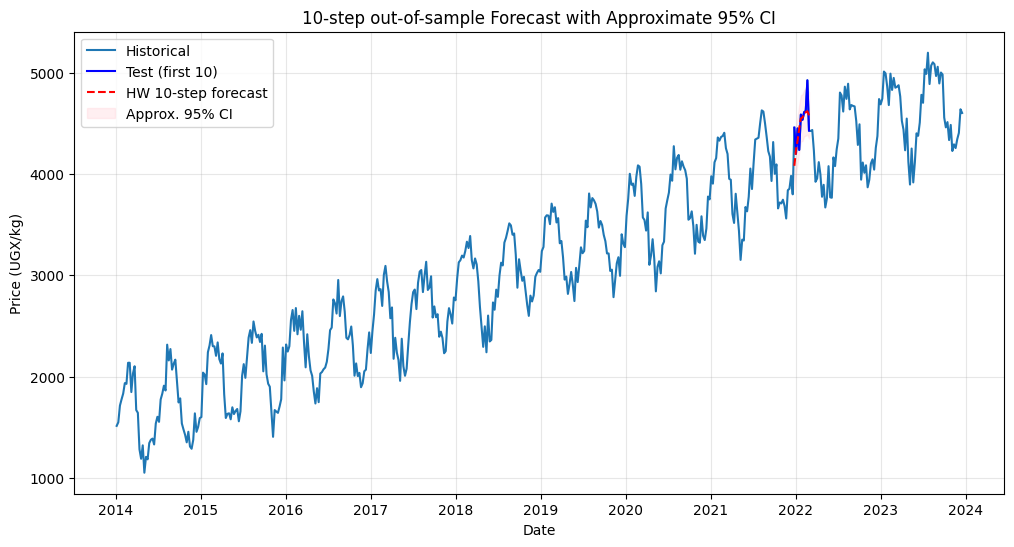

In [31]:
# Part B: 10-step out-of-sample forecast and confidence interval using the chosen final model (Holt-Winters)
forecast_horizon = 10
hw_fcast_10 = hw_model.forecast(steps=forecast_horizon)

# compute approximate CI using residual std
resid_std = hw_model.resid.std(ddof=1)
z = 1.96  # for 95% interval
hw_ci = pd.DataFrame({
    'lower Price_UGX': hw_fcast_10 - z * resid_std,
    'upper Price_UGX': hw_fcast_10 + z * resid_std
}, index=test.index[:forecast_horizon])

# Metrics functions
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test.iloc[:forecast_horizon], hw_fcast_10)
rmse = np.sqrt(mean_squared_error(test.iloc[:forecast_horizon], hw_fcast_10))
mae = mean_absolute_error(test.iloc[:forecast_horizon], hw_fcast_10)

print(f"10-step forecast MAE: {mae:.2f}")
print(f"10-step forecast RMSE: {rmse:.2f}")
print(f"10-step forecast MAPE: {100*mape:.2f}%")
print(f"Approximate 95% CI using residual std deviation: +/- {z * resid_std:.2f} UGX/kg")

# Plot forecasts
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Price_UGX'], label='Historical')
plt.plot(test.index[:forecast_horizon], test.iloc[:forecast_horizon], label='Test (first 10)', color='blue')
plt.plot(test.index[:forecast_horizon], hw_fcast_10, label='HW 10-step forecast', color='red', linestyle='--')
plt.fill_between(test.index[:forecast_horizon], hw_ci['lower Price_UGX'], hw_ci['upper Price_UGX'], color='pink', alpha=0.25, label='Approx. 95% CI')

plt.title('10-step out-of-sample Forecast with Approximate 95% CI')
plt.xlabel('Date')
plt.ylabel('Price (UGX/kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



1. Forecasting (Out-of-sample, 10-step + CI):
   - We generated a 10-step ahead forecast using the final Holt-Winters model and plotted the observed test values for the first 10 test points.
   - An approximate 95% confidence interval was computed using residual standard deviation (±229.85 UGX/kg) and displayed as a shaded region.

2. Evaluation metrics:
   - MAE (128.01 UGX/kg): Measures the average absolute forecast error. This indicates the model is off by about 128 UGX/kg on average, which is reasonable for coffee prices ranging from 1500-4800 UGX/kg.
   - RMSE (179.29 UGX/kg): Penalizes larger errors more heavily than MAE. The value shows the model handles most deviations well, but occasional larger errors contribute to this figure.
   - MAPE (2.83%): Expresses error as a percentage of actual values. A low MAPE suggests high relative accuracy, meaning the model's forecasts are within 3% of true prices on average, indicating strong performance for short-term agricultural commodity forecasting.
   - These metrics collectively reveal the model has good accuracy: low relative error (MAPE) and absolute errors that are small compared to price levels, making it suitable for practical use in coffee price prediction.

3. Reflection (Limitations):
   - The dataset is synthetic and lacks real-world shocks (climate, policy, disease, logistics), so forecast risk is understated.
   - Additive seasonality/trend assumptions may not hold for all agricultural commodities, which can require multiplicative or regime-switching behavior.
   - Fixed seasonality period (26 weeks) is a simplification; real harvest cycles can shift.
   - The model uses a single tool (Holt-Winters), while ensemble or hybrid models (SARIMA + machine learning) might improve robustness.
   - Confidence intervals rely on model assumptions and may be too narrow for volatile commodities.